In [6]:
from typing import TypedDict
from langgraph.graph import StateGraph 

In [7]:
class AgentState(TypedDict):
    name: str
    age: str
    final: str

In [ ]:
def first_node(state: AgentState) -> AgentState:
    """This is the first node in our sequence"""
    print(state)

    state['final'] = f'Hi {state['name']}!'
    
    print(state)
    
    return state

def second_node(state: AgentState) -> AgentState:
    """This is the second node in our sequence"""
    print(state)

    state['final'] = state['final'] + f' You are {state['age']} years old!'

    print(state)

    return state

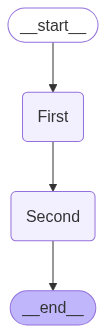

In [9]:
graph = StateGraph(AgentState)
graph.add_node('First',first_node)
graph.add_node('Second',second_node)
graph.set_entry_point('First')
graph.add_edge('First','Second')
graph.set_finish_point('Second')
graph.compile()


In [10]:
app = graph.compile()
result = app.invoke({'name':'Jayesh', 'age':'23'})

{'name': 'Jayesh', 'age': '23'}
{'name': 'Jayesh', 'age': '23', 'final': 'Hi Jayesh!'}
{'name': 'Jayesh', 'age': '23', 'final': 'Hi Jayesh!'}
{'name': 'Jayesh', 'age': '23', 'final': 'Hi Jayesh! You are 23 years old!'}
